# Atelier Scikit-learn — Prédiction de l'état d'un capteur IoT

**Objectif :** construire un modèle de Machine Learning capable de prédire automatiquement l'état d'un capteur (`OK`, `ALERTE`, `ERREUR`) à partir de ses mesures (température, humidité, pression, consommation).

**Workflow suivi :**
`Dataset → Chargement → Exploration → Nettoyage → X/y → Train/Test → Prétraitement → Modèle → fit() → predict() → Évaluation → Sauvegarde → Chargement → Réutilisation`

Structure du projet :
```
SmartSensor_SKL_ML/
├── data/mesures_capteurs.csv
├── notebooks/SmartSensor_SKL_ML.ipynb
└── models/modele_capteurs.joblib, modele_capteurs.pkl
```


### Installation, imports et chargement des données

On importe Pandas (données), Seaborn/Matplotlib (visualisation de l'évaluation), et les modules Scikit-learn nécessaires à chaque étape du pipeline.

In [3]:
# Installation si nécessaire
!pip install scikit-learn seaborn matplotlib pandas joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib
import pickle

sns.set_theme(style="whitegrid")

# Import du dataset
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [17]:
# 6) Exploration du dataframe
print("Dimensions :", df.shape)
df.info()


Dimensions : (600, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     600 non-null    object 
 1   date_heure    600 non-null    object 
 2   id_capteur    600 non-null    object 
 3   batiment      600 non-null    object 
 4   temperature   594 non-null    float64
 5   humidite      595 non-null    float64
 6   pression      595 non-null    float64
 7   consommation  595 non-null    float64
 8   etat          596 non-null    object 
dtypes: float64(4), object(5)
memory usage: 46.9+ KB


## Partie 1 : Gestion des doublons

Des mesures dupliquées fausseraient l'apprentissage du modèle (le même exemple compterait plusieurs fois) : elles doivent être supprimées avant toute étape de modélisation.

In [5]:
# 1) Vérification de l'existence de doublons
print("Nombre de doublons :", df.duplicated().sum())

# 2) Suppression puis vérification
df = df.drop_duplicates()
print("Nombre de doublons après suppression :", df.duplicated().sum())
print("Nouvelles dimensions :", df.shape)


Nombre de doublons : 5
Nombre de doublons après suppression : 0
Nouvelles dimensions : (600, 9)


## Partie 2 : Sélection de y (cible) et X (caractéristiques)

`y` est la variable à prédire (`etat`), `X` regroupe les variables explicatives utilisées pour faire cette prédiction. Une ligne dont la cible est manquante ne peut pas servir à l'apprentissage : on la retire avant de séparer X et y.

In [6]:
# On retire les lignes dont l'état (cible) est manquant : impossible d'apprendre sans cible connue
df_modele = df.dropna(subset=["etat"])
print("Lignes avec état manquant retirées :", df.shape[0] - df_modele.shape[0])

# 1) Définition de X (caractéristiques) et y (cible)
X = df_modele[["temperature", "humidite", "pression", "consommation"]]
y = df_modele["etat"]


Lignes avec état manquant retirées : 4


In [7]:
# 2) Cinq premières lignes de X et de y
print("X :")
display(X.head())
print("y :")
display(y.head())


X :


,temperature,humidite,pression,consommation
0,25.46,58.06,1008.95,287.28
1,24.00,79.73,993.39,116.20
2,25.82,54.47,1010.32,288.50
3,28.23,69.39,1019.62,136.65
4,20.58,53.80,1016.58,182.62


y :


0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: object

**3) Type de problème :** c'est un problème de **classification multi-classe supervisée** : on cherche à prédire une catégorie parmi trois (`OK`, `ALERTE`, `ERREUR`) à partir de variables numériques.

## Partie 3 : Découpage Train/Test

On sépare les données en un ensemble d'entraînement (pour apprendre) et un ensemble de test (pour évaluer sur des données jamais vues). `stratify=y` garantit que les proportions de chaque classe (OK/ALERTE/ERREUR) restent identiques dans les deux ensembles — important ici car les classes sont déséquilibrées.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% pour le test
    random_state=42,     # reproductibilité du découpage
    stratify=y            # conserve les proportions de classes
)

print("Taille X_train :", X_train.shape, "| Taille X_test :", X_test.shape)
print("Proportions dans y_train :\n", y_train.value_counts(normalize=True).round(3))
print("Proportions dans y_test :\n", y_test.value_counts(normalize=True).round(3))


Taille X_train : (476, 4) | Taille X_test : (120, 4)
Proportions dans y_train :
 etat
OK        0.943
ALERTE    0.048
ERREUR    0.008
Name: proportion, dtype: float64
Proportions dans y_test :
 etat
OK        0.942
ALERTE    0.050
ERREUR    0.008
Name: proportion, dtype: float64


## Partie 4 : Gestion des valeurs manquantes

Un modèle Scikit-learn ne peut pas être entraîné sur des `NaN` : il faut les imputer (remplacer) avant l'entraînement. **L'imputeur est toujours ajusté (`fit`) sur `X_train` uniquement**, puis appliqué à `X_train` et `X_test`, pour éviter toute fuite d'information (*data leakage*) depuis l'ensemble de test.

In [9]:
# 1) Vérification des valeurs manquantes
print("Valeurs manquantes dans X_train :\n", X_train.isna().sum())


Valeurs manquantes dans X_train :
 temperature     5
humidite        4
pression        5
consommation    3
dtype: int64


In [10]:
# 2) SimpleImputer avec la stratégie médiane
imputer = SimpleImputer(strategy="median")

**3) Pourquoi la médiane plutôt que la moyenne ?** La médiane est **robuste aux valeurs extrêmes (outliers)** : contrairement à la moyenne, une valeur aberrante ne la fait pas dévier fortement. Comme nos données de capteurs contiennent des pics anormaux (température, consommation), la médiane donne une valeur de remplacement plus représentative de la tendance centrale réelle.

In [11]:
# 4) Apprentissage des paramètres (médianes) sur X_train uniquement
imputer.fit(X_train)
print("Médianes apprises (par colonne) :", dict(zip(X_train.columns, imputer.statistics_)))


Médianes apprises (par colonne) : {'temperature': np.float64(24.9), 'humidite': np.float64(65.38), 'pression': np.float64(1012.3), 'consommation': np.float64(206.59)}


In [14]:
# 5) Transformation de X_train et X_test
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Valeurs manquantes restantes dans X_train_imputed :", X_train_imputed.isna().sum().sum())
X_train_imputed.head()

Valeurs manquantes restantes dans X_train_imputed : 0


,temperature,humidite,pression,consommation
99,26.14,84.97,1003.59,142.31
479,22.27,44.03,1005.85,138.16
195,28.13,75.78,1003.24,242.62
250,25.51,68.57,1024.71,96.51
129,33.60,79.80,1021.96,212.55


## Partie 5 : Mise à l'échelle

Les variables n'ont pas la même échelle (la pression varie autour de 1000+, la température autour de 25) : sans standardisation, les variables à grande échelle domineraient artificiellement le calcul de distance du modèle KNN. `StandardScaler` centre-réduit chaque variable (`moyenne = 0`, `écart-type = 1`).

In [12]:
# 1) Sélection de StandardScaler
scaler = StandardScaler()


**2) Pourquoi standardiser ?** Le modèle KNN (partie suivante) se base sur des **distances entre points**. Sans mise à l'échelle, une variable comme la pression (valeurs ~1000) écraserait complètement l'influence de la température (valeurs ~20-30) dans le calcul de distance, même si les deux variables sont aussi informatives l'une que l'autre.

In [15]:
# 3) Apprentissage des paramètres (moyennes, écarts-types) sur X_train_imputed
scaler.fit(X_train_imputed)
print("Moyennes apprises :", dict(zip(X_train.columns, scaler.mean_.round(2))))
print("Écarts-types appris :", dict(zip(X_train.columns, scaler.scale_.round(2))))


Moyennes apprises : {'temperature': np.float64(24.96), 'humidite': np.float64(64.85), 'pression': np.float64(1012.08), 'consommation': np.float64(210.15)}
Écarts-types appris : {'temperature': np.float64(4.19), 'humidite': np.float64(10.16), 'pression': np.float64(10.99), 'consommation': np.float64(73.42)}


In [16]:
# 4) Transformation de X_train_imputed et X_test_imputed
X_train_scaled = pd.DataFrame(scaler.transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().round(2)


,temperature,humidite,pression,consommation
count,476.00,476.00,476.00,476.00
mean,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-10.37,-2.86,-14.74,-2.62
25%,-0.55,-0.66,-0.49,-0.68
50%,-0.02,0.05,0.02,-0.05
75%,0.56,0.66,0.52,0.61
max,8.05,2.78,2.40,9.06


## Partie 6 : Entraînement et prédiction d'un modèle

Le modèle **KNN (k plus proches voisins)** classe une nouvelle mesure en regardant les `k` mesures les plus proches (en distance) dans les données d'entraînement, et retient la classe majoritaire parmi elles.

In [18]:
# 1) Sélection du modèle KNN avec k=5
modele = KNeighborsClassifier(n_neighbors=5)

# 2) Entraînement du modèle
modele.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [19]:
# 3) Prédictions sur l'ensemble de test
y_pred = modele.predict(X_test_scaled)

# 4) Quelques prédictions
print("Premières prédictions :", y_pred[:10])


Premières prédictions : ['OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK']


In [20]:
# 5) Comparaison prédictions vs vraies valeurs
comparaison = pd.DataFrame({
    "Valeur réelle": y_test.values[:10],
    "Prédiction": y_pred[:10]
})
comparaison


,Valeur réelle,Prédiction
0,OK,OK
1,OK,OK
2,OK,OK
3,OK,OK
4,ALERTE,OK
5,OK,OK
6,OK,OK
7,OK,OK
8,OK,OK
9,OK,OK


## Partie 7 : Évaluation du modèle

Plusieurs métriques permettent de juger la qualité des prédictions, chacune éclairant un aspect différent des erreurs commises par le modèle.

In [21]:
# 1) Évaluation avec l'Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.3f}")


Accuracy : 0.958


**2) Pourquoi l'Accuracy ne suffit pas toujours ?** Nos classes sont **déséquilibrées** (très majoritairement `OK`, peu d'`ALERTE`/`ERREUR`). Un modèle qui prédirait systématiquement `OK` obtiendrait déjà une accuracy élevée, tout en étant **inutile** puisqu'il ne détecterait jamais les vraies anomalies — l'objectif même de l'atelier. Il faut donc regarder aussi comment le modèle se comporte sur les classes minoritaires.

In [22]:
# 3) Matrice de confusion
labels = sorted(y.unique())
matrice_confusion = confusion_matrix(y_test, y_pred, labels=labels)
print("Classes :", labels)
print(matrice_confusion)


Classes : ['ALERTE', 'ERREUR', 'OK']
[[  2   0   4]
 [  1   0   0]
 [  0   0 113]]


**Commentaire :** chaque ligne représente la vraie classe, chaque colonne la classe prédite. Les valeurs sur la **diagonale** sont les prédictions correctes ; les valeurs **hors diagonale** sont les erreurs (ex : une mesure réellement en `ALERTE` prédite à tort comme `OK`).

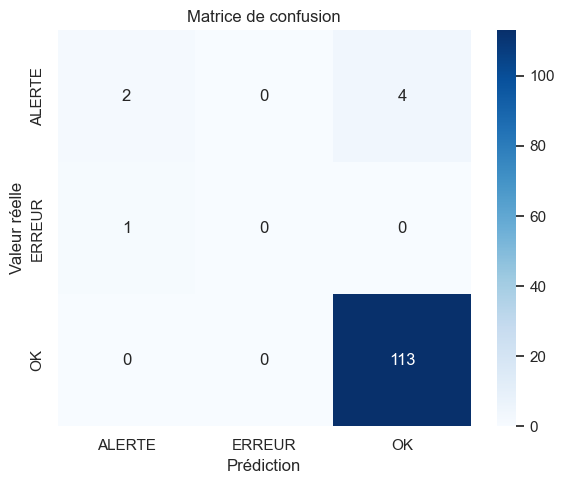

In [23]:
# 4) Visualisation de la matrice de confusion avec Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(matrice_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.tight_layout()
plt.show()


In [24]:
# 5) Rapport de classification
print(classification_report(y_test, y_pred, labels=labels))


              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

**Commentaire :** le rapport détaille, pour chaque classe, la **precision** (parmi les mesures prédites dans cette classe, combien le sont réellement), le **recall** (parmi les mesures réellement dans cette classe, combien ont été retrouvées) et le **F1-score** (moyenne harmonique des deux). La classe `OK`, majoritaire, obtient généralement de bons scores, tandis que les classes rares (`ALERTE`, `ERREUR`) sont plus difficiles à bien prédire faute d'exemples suffisants.

**6) Quelle métrique privilégier selon le contexte ?**
- **Precision** : quand le coût d'une **fausse alerte** est élevé (ex : déclencher une intervention technique coûteuse à tort).
- **Recall** : quand le coût de **rater une vraie anomalie** est élevé (ex : ne pas détecter une panne réelle d'un capteur critique) — souvent prioritaire dans un système de détection d'anomalies.
- **F1-score** : quand on veut un **compromis** entre precision et recall, notamment sur des classes déséquilibrées comme ici.
- **Accuracy** : pertinente seulement quand les **classes sont équilibrées** ; sinon elle peut masquer une mauvaise détection des classes minoritaires, comme expliqué au point 2.

## Partie 8 : Sauvegarde du modèle

On sauvegarde le modèle entraîné **ainsi que l'imputeur et le scaler**, indispensables pour appliquer exactement le même prétraitement à une nouvelle mesure lors de la réutilisation.

In [25]:
import os
os.makedirs("../models", exist_ok=True)

objets_a_sauvegarder = {
    "modele": modele,
    "imputer": imputer,
    "scaler": scaler,
    "colonnes": list(X.columns)
}

# 1) Sauvegarde avec Joblib
joblib.dump(objets_a_sauvegarder, "../models/modele_capteurs.joblib")

# 2) Sauvegarde avec Pickle
with open("../models/modele_capteurs.pkl", "wb") as f:
    pickle.dump(objets_a_sauvegarder, f)

print("Modèle sauvegardé (Joblib et Pickle).")


Modèle sauvegardé (Joblib et Pickle).


## Partie 9 : Chargement du modèle

On recharge le modèle sauvegardé pour vérifier qu'il est directement réutilisable, sans avoir à refaire l'entraînement.

In [26]:
# 1) Chargement du modèle (ici via Joblib)
objets_charges = joblib.load("../models/modele_capteurs.joblib")

modele_charge = objets_charges["modele"]
imputer_charge = objets_charges["imputer"]
scaler_charge = objets_charges["scaler"]
colonnes = objets_charges["colonnes"]

print("Modèle chargé :", modele_charge)


Modèle chargé : KNeighborsClassifier()


In [27]:
# 2) Prédiction sur une nouvelle mesure
nouvelle_mesure = pd.DataFrame([{
    "temperature": 32.5,
    "humidite": 78,
    "pression": 1008,
    "consommation": 410
}])[colonnes]

# Même prétraitement que pour l'entraînement : imputation puis mise à l'échelle
nouvelle_mesure_imputed = imputer_charge.transform(nouvelle_mesure)
nouvelle_mesure_scaled = scaler_charge.transform(nouvelle_mesure_imputed)

prediction = modele_charge.predict(nouvelle_mesure_scaled)
print("État prédit pour la nouvelle mesure :", prediction[0])


État prédit pour la nouvelle mesure : OK


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Partie 10 : Bonus

Deux ajouts utiles : chercher la **meilleure valeur de k** pour le KNN plutôt que de la fixer arbitrairement, et comparer avec un second modèle (**RandomForest**) pour voir si un autre algorithme fait mieux sur les classes minoritaires.

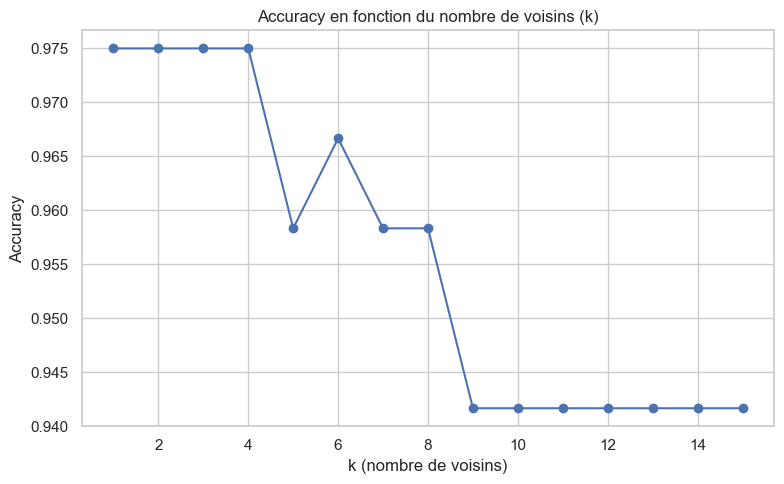

Meilleur k trouvé : 1 - Accuracy : 0.975


In [28]:
# Bonus 1 : recherche du meilleur k (de 1 à 15) selon l'accuracy sur le test
accuracies = []
valeurs_k = range(1, 16)

for k in valeurs_k:
    modele_k = KNeighborsClassifier(n_neighbors=k)
    modele_k.fit(X_train_scaled, y_train)
    y_pred_k = modele_k.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(8, 5))
plt.plot(list(valeurs_k), accuracies, marker="o")
plt.title("Accuracy en fonction du nombre de voisins (k)")
plt.xlabel("k (nombre de voisins)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

meilleur_k = list(valeurs_k)[int(np.argmax(accuracies))]
print("Meilleur k trouvé :", meilleur_k, "- Accuracy :", round(max(accuracies), 3))


In [29]:
# Bonus 2 : comparaison avec un RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

modele_rf = RandomForestClassifier(n_estimators=200, random_state=42)
modele_rf.fit(X_train_scaled, y_train)
y_pred_rf = modele_rf.predict(X_test_scaled)

print("Accuracy KNN (k=5) :", round(accuracy_score(y_test, y_pred), 3))
print("Accuracy RandomForest :", round(accuracy_score(y_test, y_pred_rf), 3))
print()
print("Rapport de classification - RandomForest :")
print(classification_report(y_test, y_pred_rf, labels=labels))


Accuracy KNN (k=5) : 0.958
Accuracy RandomForest : 0.983

Rapport de classification - RandomForest :
              precision    recall  f1-score   support

      ALERTE       0.83      0.83      0.83         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.99      1.00      1.00       113

    accuracy                           0.98       120
   macro avg       0.61      0.61      0.61       120
weighted avg       0.98      0.98      0.98       120



c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif